# Importation

In [ ]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pyoperators import (
    MPI,
    BlockDiagonalOperator,
    BlockRowOperator,
    Cartesian2SphericalOperator,
    DiagonalOperator,
    IdentityOperator,
    ReshapeOperator,
    Rotation3dOperator,
    Spherical2CartesianOperator,
)
from pyoperators.iterative.core import AbnormalStopIteration
from pysimulators.interfaces.healpy import (
    HealpixConvolutionGaussianOperator,
    Spherical2HealpixOperator,
)

from qubic.lib.Instrument.Qacquisition import QubicAcquisition
from qubic.lib.Instrument.Qinstrument import QubicInstrument
from qubic.lib.MapMaking.FrequencyMapMaking.Qspectra_component import CMBModel
from qubic.lib.MapMaking.Qatmosphere import AtmosphereMaps
from qubic.lib.MapMaking.Qcg_test_for_atm import PCGAlgorithm
from qubic.lib.Qsamplings import QubicSampling, equ2gal, get_pointing
from qubic.lib.Qscene import QubicScene

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

%matplotlib inline

hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).


In [ ]:
# Import simulation parameters
with open("params.yml", "r") as file:
    params = yaml.safe_load(file)

params["flat"] = True

In [3]:
# Call the class which build the atmosphere maps
atm = AtmosphereMaps(params)
qubic_dict = atm.qubic_dict

In [4]:
qubic_dict

{'debug': False,
 'config': 'FI',
 'filter_nu': 150000000000.0,
 'filter_relative_bandwidth': 0.25,
 'beam_shape': 'gaussian',
 'MultiBand': True,
 'nf_sub': 8,
 'center_detector': False,
 'psd': None,
 'bandwidth': None,
 'twosided': None,
 'sigma': None,
 'detector_nep': 4.7e-17,
 'detector_fknee': 0,
 'detector_fslope': 1,
 'detector_ncorr': 10,
 'detector_ngrids': 1,
 'detector_tau': 0.01,
 'polarizer': True,
 'synthbeam_fraction': 1,
 'synthbeam_kmax': 1,
 'synthbeam_peak150_fwhm': 0.39268176,
 'ripples': False,
 'nripples': 0,
 'focal_length': 0.3,
 'optics': 'CalQubic_Optics_v3_CC_FFF.txt',
 'primbeam': 'CalQubic_PrimBeam_v2.fits',
 'detarray': 'CalQubic_DetArray_v4_CC.fits',
 'hornarray': 'CalQubic_HornArray_CC.fits',
 'synthbeam': 'CalQubic_Synthbeam_Analytical_220_FI.fits',
 'nside': 128,
 'kind': 'IQU',
 'absolute': False,
 'temperature': 2.7255,
 'summer': False,
 'RA_center': 0,
 'DEC_center': -57,
 'period': 1,
 'date_obs': '2016-01-01 00:00:00',
 'latitude': -24.18333333

# Scanning Strategy

## Galactic Coordinates - Sweeping scan following the center of the Qubic patch

In [5]:
### Random pointing
qubic_dict["random_pointing"] = True

### Sweepingpointing
qubic_dict["sweeping_pointing"] = False
qubic_dict["fix_azimuth"]["apply"] = False

qubic_dict["angspeed"] = 0.4
qubic_dict["delta_az"] = 20
qubic_dict["nsweeps_per_elevation"] = 1
qubic_dict["period"] = 1
qubic_dict["duration"] = 1
# npointings = 3600 * t_obs / period

### Repeat pointing
qubic_dict["repeat_pointing"] = False

qubic_dict["fix_azimuth"]["apply"] = False

q_sampling_gal = get_pointing(qubic_dict)
qubic_patch = np.array([0, -57])
center_gal = equ2gal(qubic_patch[0], qubic_patch[1])
center_local = np.array(
    [np.mean(q_sampling_gal.azimuth), np.mean(q_sampling_gal.elevation)]
)
print(q_sampling_gal)

QubicSampling((5000,), 
    index=[   0    1    2 ... 4997 4998 4999],
    angle_hwp=[30 75 30 ... 75 60 45],
    azimuth=[221.83069691 213.53500946 189.90337455 ... 199.03733951 213.2766,
    elevation=[43.42925969 42.5054719  40.75391101 ... 39.16393619 39.70383112
,
    equatorial=[[343.55767673 -50.82827123]
 [345.46653981 -56.86269522]
 [  9.4,
    galactic=[[338.09662836 -57.53681203]
 [328.57476872 -54.46712519]
 [304.4,
    masked=False,
    pitch=[275.57890577 110.94219781 264.7360378  ... 249.15064757  65.0759)


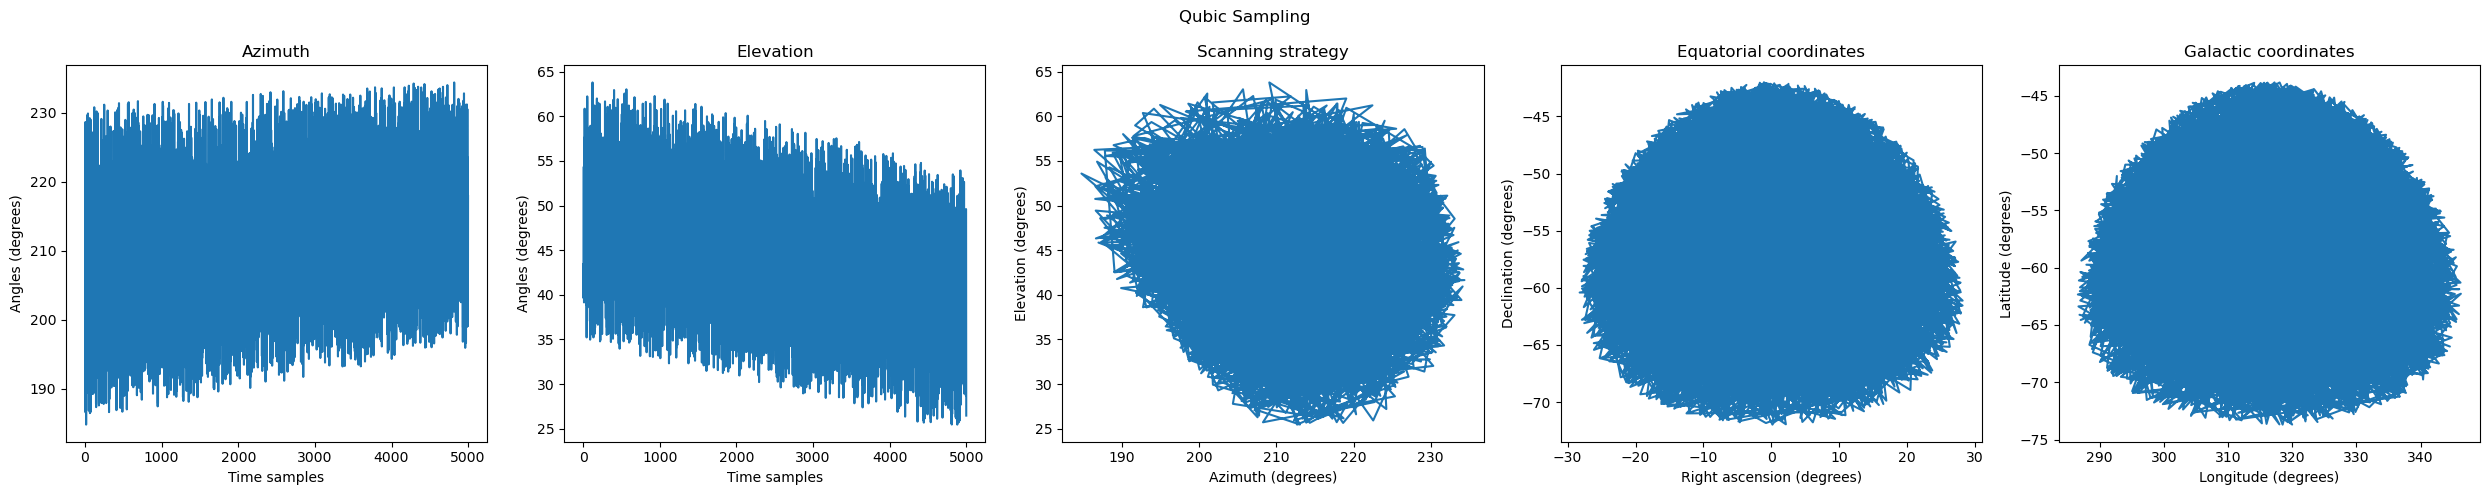

In [ ]:
az, el = q_sampling_gal.azimuth, q_sampling_gal.elevation

fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# Azimuth plot
axs[0].plot(az)
axs[0].set_title("Azimuth")
axs[0].set_xlabel("Time samples")
axs[0].set_ylabel("Angles (degrees)")

# Elevation plot
axs[1].plot(el)
axs[1].set_title("Elevation")
axs[1].set_xlabel("Time samples")
axs[1].set_ylabel("Angles (degrees)")

# Scanning strategy plot
axs[2].plot(az, el)
axs[2].set_title("Scanning strategy")
axs[2].set_xlabel("Azimuth (degrees)")
axs[2].set_ylabel("Elevation (degrees)")

# Equatorial coordinates plot
axs[3].plot(
    (q_sampling_gal.equatorial[:, 0] + 180) % 360 - 180, q_sampling_gal.equatorial[:, 1]
)
axs[3].set_title("Equatorial coordinates")
axs[3].set_xlabel("Right ascension (degrees)")
axs[3].set_ylabel("Declination (degrees)")

# Galactic coordinates plot
axs[4].plot(q_sampling_gal.galactic[:, 0], q_sampling_gal.galactic[:, 1])
axs[4].set_title("Galactic coordinates")
axs[4].set_xlabel("Longitude (degrees)")
axs[4].set_ylabel("Latitude (degrees)")

fig.suptitle("Qubic Sampling")
plt.tight_layout()
plt.show()

In [7]:
int(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians(np.mean(q_sampling_gal.galactic, axis=0))
    )
)

181946

In [8]:
print(q_sampling_gal.galactic)

[[338.09662836 -57.53681203]
 [328.57476872 -54.46712519]
 [304.49035797 -45.61402985]
 ...
 [303.42980308 -49.1027323 ]
 [314.19884696 -58.0887693 ]
 [335.09274589 -51.27518247]]


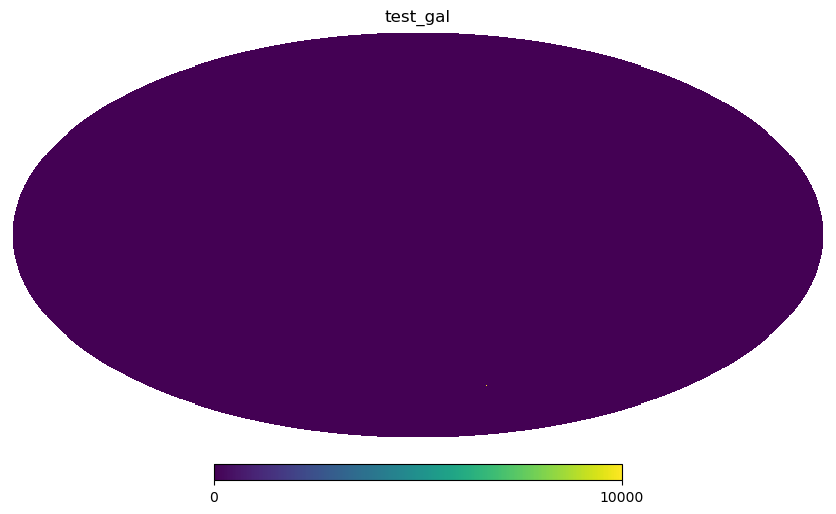

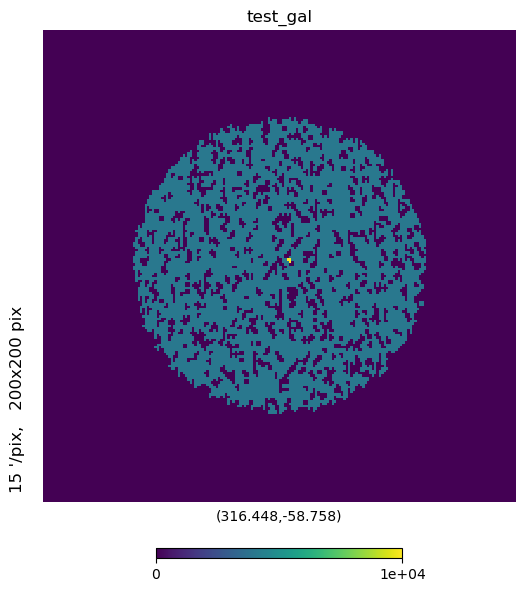

In [9]:
test_gal = np.zeros(hp.nside2npix(params["nside"]))

coord_test_gal = np.radians(q_sampling_gal.galactic[-2])

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians(q_sampling_gal.galactic)
    ),
    dtype="int",
)
test_gal[index] = 1
test_gal[
    int(
        Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(coord_test_gal)
    )
] = 1e4
hp.mollview(test_gal, title="test_gal", cmap="viridis")
hp.gnomview(
    test_gal, title="test_gal", cmap="viridis", reso=15, rot=center_gal, norm="hist"
)

## Local Coordinates - Sweeping scan following the center of the Qubic patch

In [ ]:
q_sampling_local = QubicSampling(
    params[
        "npointings"
    ],  # int(np.ceil(qubic_dict['duration']*3600/qubic_dict['period'])),
    date_obs=qubic_dict["date_obs"],
    period=qubic_dict["period"],
    latitude=qubic_dict["latitude"],
    longitude=qubic_dict["longitude"],
)

q_sampling_local.azimuth = q_sampling_gal.azimuth
q_sampling_local.elevation = q_sampling_gal.elevation
q_sampling_local.pitch = q_sampling_gal.pitch
q_sampling_local.angle_hwp = q_sampling_gal.angle_hwp

q_sampling_local.fix_az = True

211.92662822765195 43.93466164903442


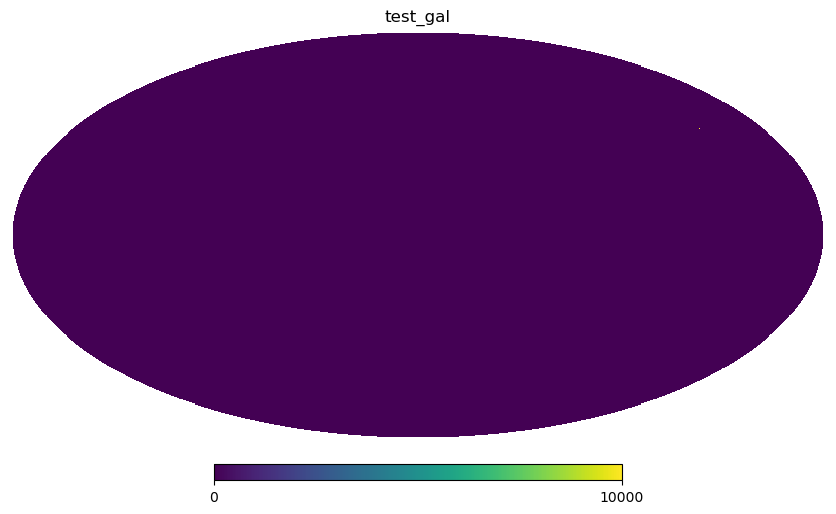

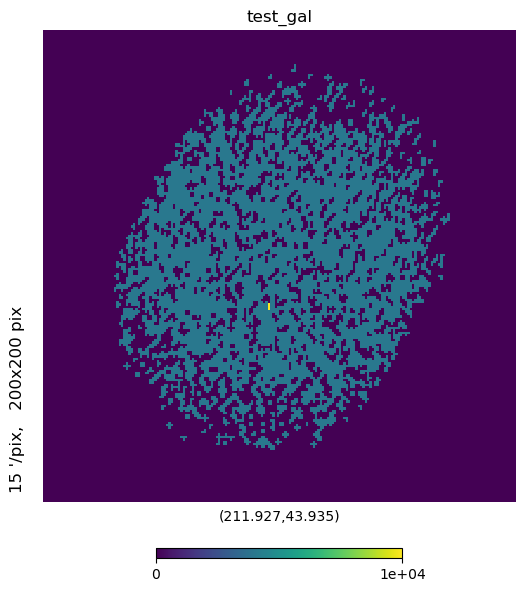

In [11]:
test_gal = np.zeros(hp.nside2npix(params["nside"]))

coord_test_local = np.radians(
    [q_sampling_local.azimuth[-2], q_sampling_local.elevation[-2]]
).T

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians([q_sampling_local.azimuth, q_sampling_local.elevation]).T
    ),
    dtype="int",
)
test_gal[index] = 1
test_gal[
    int(
        Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
            coord_test_local
        )
    )
] = 1e4
hp.mollview(test_gal, title="test_gal", cmap="viridis")
hp.gnomview(
    test_gal,
    title="test_gal",
    cmap="viridis",
    norm="hist",
    reso=15,
    rot=(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation)),
)


print(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation))

# Input Maps

## CMB

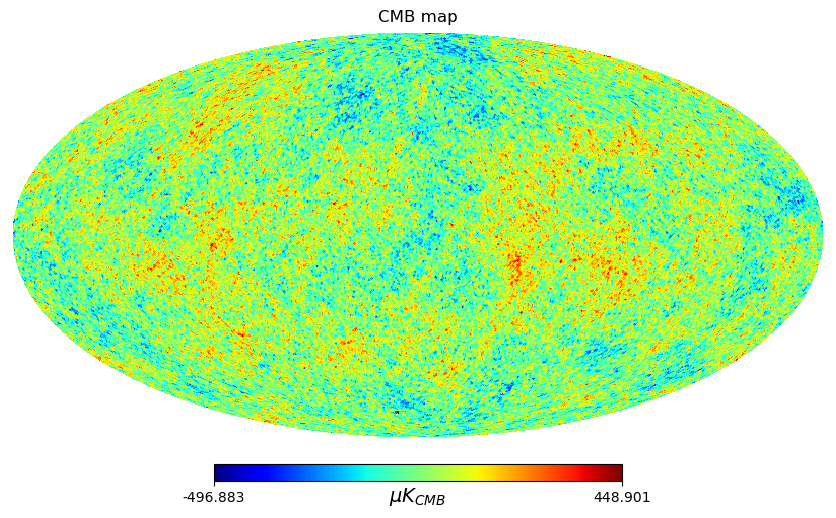

In [ ]:
# Build CMB map
cl_cmb = CMBModel(None).give_cl_cmb(r=0, Alens=1)
cmb_map = hp.synfast(cl_cmb, params["nside"], new=True, verbose=False).T

cmb_map[..., 1] *= 0
cmb_map[..., 2] *= 0

hp.mollview(cmb_map[:, 0], cmap="jet", title="CMB map", unit=r"$µK_{CMB}$")

## Atmosphere

1000


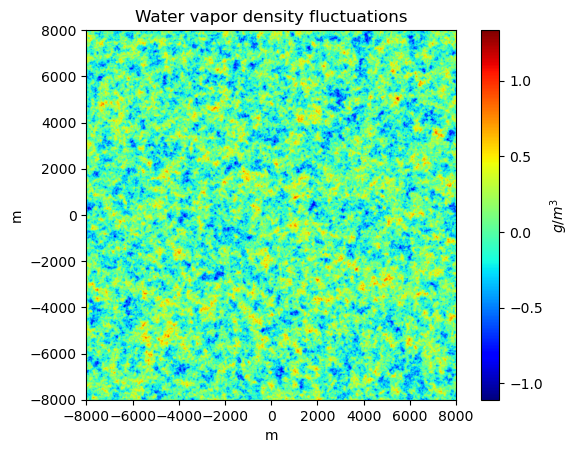

In [13]:
wv_fluctuations = atm.delta_rho_map
print(wv_fluctuations.shape[0])
plt.imshow(
    wv_fluctuations,
    cmap="jet",
    extent=[
        -params["size_atm"],
        params["size_atm"],
        -params["size_atm"],
        params["size_atm"],
    ],
)
plt.title("Water vapor density fluctuations")
plt.xlabel("m")
plt.ylabel("m")
plt.colorbar(label=r"$g/m^{3}$")

In [14]:
print("Frequencies are : ", atm.frequencies, "GHz.")

Frequencies are :  [135.50540829 144.29216391 153.6486907  163.61193508 198.74126549
 211.62850707 225.35141303 239.96417145] GHz.


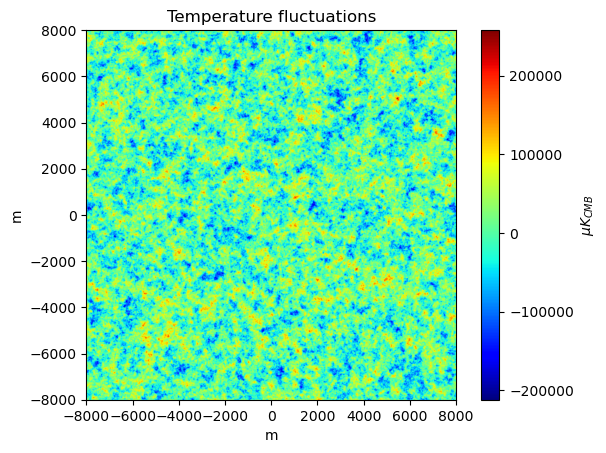

In [15]:
temp_fluctuations = np.zeros((wv_fluctuations.shape[0], wv_fluctuations.shape[1], 3))
temp_fluctuations[..., 0] = atm.get_temp_maps(wv_fluctuations)[0]
temp_fluctuations[..., 0] -= np.mean(temp_fluctuations[..., 0])

plt.imshow(
    temp_fluctuations[..., 0],
    cmap="jet",
    extent=[
        -params["size_atm"],
        params["size_atm"],
        -params["size_atm"],
        params["size_atm"],
    ],
)
plt.title("Temperature fluctuations")
plt.xlabel("m")
plt.ylabel("m")
plt.colorbar(label=r"$\mu K_{CMB}$")

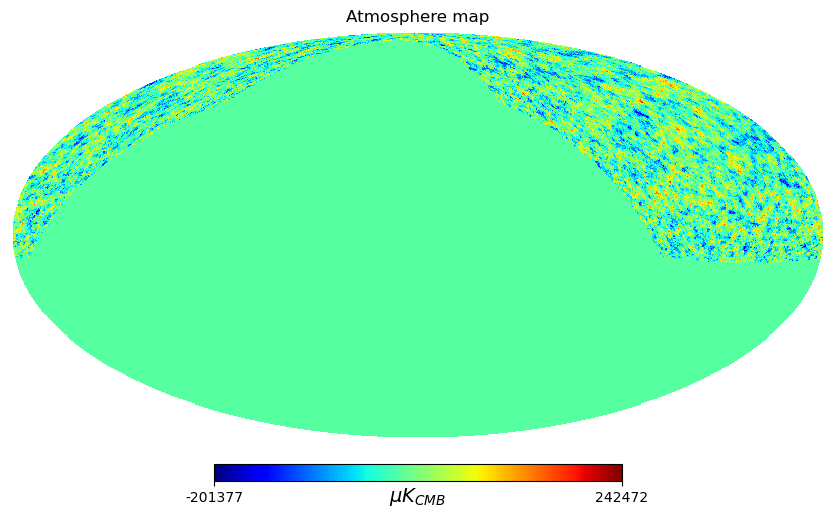

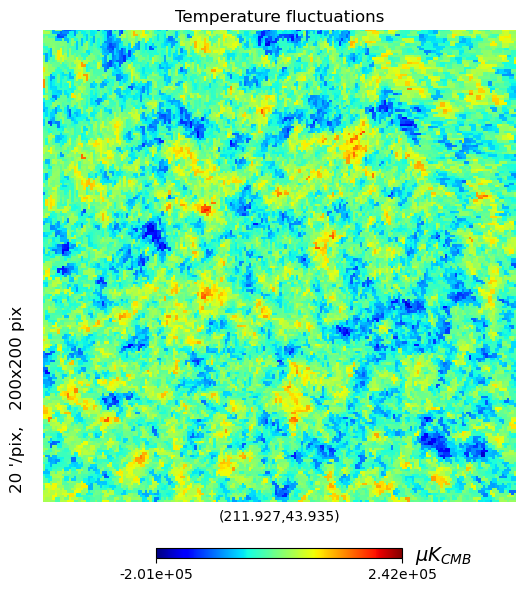

In [ ]:
atm_map = np.zeros((hp.nside2npix(params["nside"]), 3))
# atm_map[..., 0] = atm.get_healpy_atm_maps_2d(atm.get_temp_maps(wv_fluctuations))[0]

az, el = np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation)
qubic_patch = np.array([[az, el]])
azel_coordinates = atm.get_azel_coordinates()
proj_hp = Cartesian2SphericalOperator("azimuth,elevation")(
    Rotation3dOperator("ZY'", az, 90 - el, degrees=True)(
        Spherical2CartesianOperator("azimuth,elevation")
    )
)
azel2hp = Spherical2HealpixOperator(params["nside"], "azimuth,elevation")
hp_maps_index = azel2hp(proj_hp(azel_coordinates)).astype(int)
atm_map[hp_maps_index, 0] = atm.get_temp_maps(wv_fluctuations)[0].flatten()

index = np.where(atm_map != 0)[0]
atm_map[index, 0] -= np.mean(atm_map[index, 0])
min = np.min(atm_map[index, 0])
max = np.max(atm_map[index, 0])

hp.mollview(
    atm_map[..., 0],
    min=min,
    max=max,
    cmap="jet",
    title="Atmosphere map",
    unit=r"$µK_{CMB}$",
)
hp.gnomview(
    atm_map[..., 0],
    min=min,
    max=max,
    rot=qubic_patch,
    reso=20,
    cmap="jet",
    title="Temperature fluctuations",
    unit=r"$µK_{CMB}$",
)

# Build QUBIC Instances

In [ ]:
q_instrument = QubicInstrument(qubic_dict)
q_scene = QubicScene(qubic_dict)

#! Verify that using the same dictionary is not an issue for the two objects
q_acquisition_local = QubicAcquisition(
    q_instrument, q_sampling_local, q_scene, qubic_dict
)
q_acquisition_gal = QubicAcquisition(q_instrument, q_sampling_gal, q_scene, qubic_dict)

In [18]:
coverage_gal = q_acquisition_gal.get_coverage()
covnorm_gal = coverage_gal / coverage_gal.max()
seenpix_gal = covnorm_gal > params["coverage_cut"]
seenpix_gal_wo_cut = covnorm_gal > 0

coverage_local = q_acquisition_local.get_coverage()
covnorm_local = coverage_local / coverage_local.max()
seenpix_local = covnorm_local > params["coverage_cut"]
seenpix_local_wo_cut = covnorm_local > 0

seenpix = np.array([seenpix_gal, seenpix_local])

Info apcnb2325: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.


# Build QUBIC Operaotors

In [19]:
# Convolution operator
C_qubic = HealpixConvolutionGaussianOperator(fwhm=0.00628339517640407)

In [20]:
# Galactic Coordinates

H_gal = q_acquisition_gal.get_operator()
R_gal = ReshapeOperator(H_gal.shapeout, H_gal.shape[0])
invN_gal = IdentityOperator()
d_gal = H_gal(C_qubic(cmb_map)).ravel()

print("H_gal", H_gal.shapein, H_gal.shapeout)
print("R_gal", R_gal.shapein, R_gal.shapeout)
print("invN_gal", invN_gal.shapein, invN_gal.shapeout)
print("d_gal", d_gal.shape)

Info apcnb2325: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
H_gal (196608, 3) (992, 5000)
R_gal (992, 5000) (4960000,)
invN_gal None None
d_gal (4960000,)


In [21]:
# Local Coordinates

H_local = q_acquisition_local.get_operator()
R_local = ReshapeOperator(H_local.shapeout, H_local.shape[0])
invN_local = IdentityOperator()
d_local = H_local(C_qubic(atm_map)).ravel()

print("H_local", H_local.shapein, H_local.shapeout)
print("R_local", R_local.shapein, R_local.shapeout)
print("invN_local", invN_local.shapein, invN_local.shapeout)
print("d_local", d_local.shape)

Info apcnb2325: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
H_local (196608, 3) (992, 5000)
R_local (992, 5000) (4960000,)
invN_local None None
d_local (4960000,)


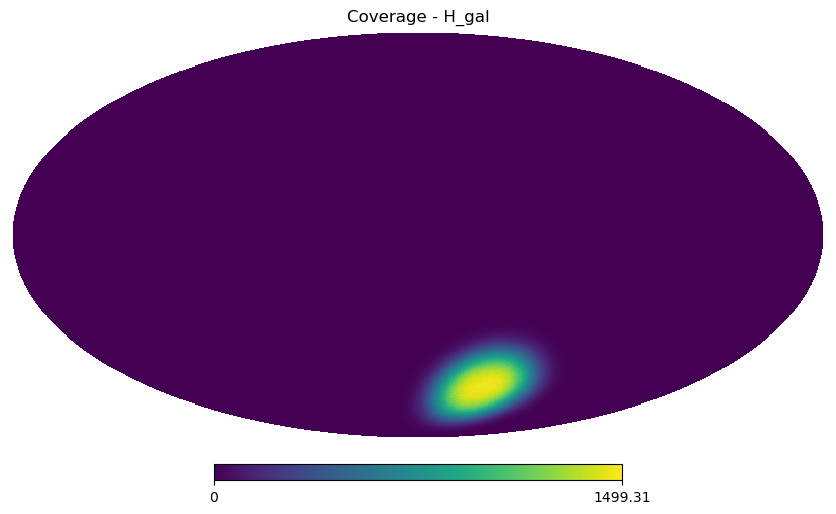

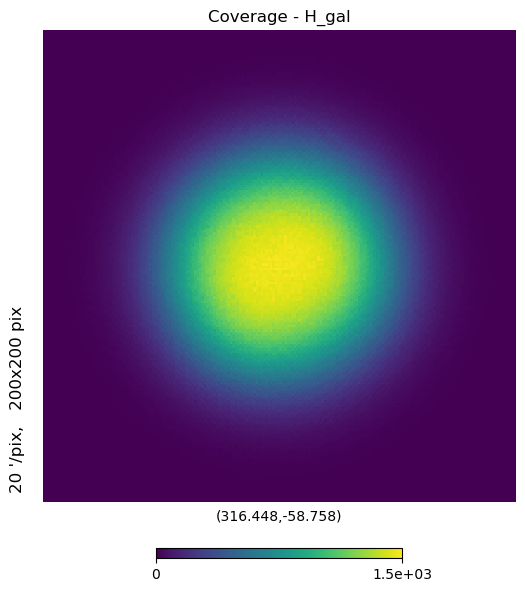

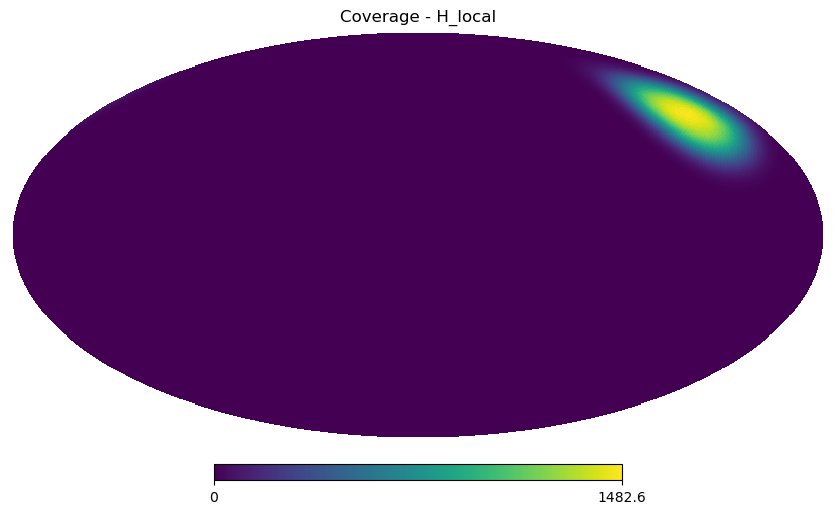

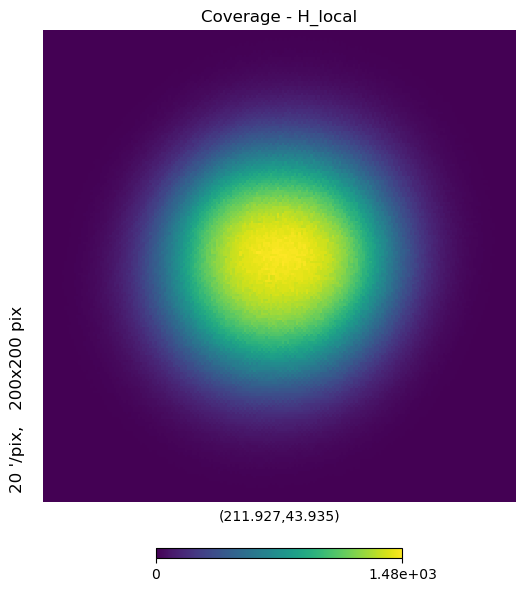

In [22]:
# Plot coverages
hp.mollview(coverage_gal, title="Coverage - H_gal")
hp.gnomview(coverage_gal, title="Coverage - H_gal", rot=center_gal, reso=20)
hp.mollview(coverage_local, title="Coverage - H_local")
hp.gnomview(coverage_local, title="Coverage - H_local", rot=center_local, reso=20)

In [ ]:
# Full MM

R = ReshapeOperator(
    (2, hp.nside2npix(params["nside"]), 3), (2 * hp.nside2npix(params["nside"]), 3)
)
H = BlockRowOperator([H_gal, H_local], axisin=0) * R

invN = invN_gal

true_maps = np.array([C_qubic(cmb_map), C_qubic(atm_map)])
d = d_gal + d_local

In [24]:
print("H", H.shapein, H.shapeout)
print("invN", invN.shapein, invN.shapeout)
print("d", d.shape)
print("True maps", true_maps.shape)

H (2, 196608, 3) (992, 5000)
invN None None
d (4960000,)
True maps (2, 196608, 3)


# Map-Making

In [25]:
# Ax=b equation to be solve by PCG
A = H.T * invN * H
R = ReshapeOperator(d.shape, H.T.shapein)
b = H.T * R * d

# I start from an atm map for the CMB and from a cmb map for the atmosphere
x0 = true_maps * 0

In [26]:
print("A", A.shapein, A.shapeout)
print("Ax", A(x0).shape)
print("b", b.shape)
print("true_maps", true_maps.shape)

A (2, 196608, 3) (2, 196608, 3)
Ax (2, 196608, 3)
b (2, 196608, 3)
true_maps (2, 196608, 3)


In [27]:
H.operands

[BlockRowOperator([
     CompositionOperator([
         ConvolutionTruncatedExponentialOperator(0.01, None, shapein=(992,5000), shapeout=(992,5000)),
         DiagonalOperator(array([0.0002985155745473152, ..., 0.0002985155745473152], dtype=float64), broadcast='rightward', None),
         ReshapeOperator((992,5000,1), (992,5000), None),
         DenseBlockDiagonalOperator(array([[[[6.550564070538102e-20, ..., 8.022127321594143e-36]]]], dtype=float64), naxesin=1, naxesout=1, None, shapein=(992,5000,3), shapeout=(992,5000,1)),
         ProjectionOperator(None, None, shapein=(196608,3), shapeout=(992,5000,3))]),
     CompositionOperator([
         ConvolutionTruncatedExponentialOperator(0.01, None, shapein=(992,5000), shapeout=(992,5000)),
         DiagonalOperator(array([0.0002985155745473152, ..., 0.0002985155745473152], dtype=float64), broadcast='rightward', None),
         ReshapeOperator((992,5000,1), (992,5000), None),
         DenseBlockDiagonalOperator(array([[[[6.550564070538102e

In [ ]:
# Build Preconditionner
no_det = 992

stacked_dptdp_inv = np.zeros((true_maps.shape[0], 12 * params["nside"] ** 2))

### Loop on Maps
for i_maps in range(true_maps.shape[0]):
    ### Extract Operators
    h = H.operands[0].operands[i_maps]
    D = h.operands[1]
    P = h.operands[-1]
    sh = P.matrix.data.index.shape

    ### Compute the map P^t P
    point_per_det = int(sh[0] / no_det)
    mapPtP_perdet_seq = np.zeros((no_det, 12 * params["nside"] ** 2))
    sample_ranges = [
        (det * point_per_det, (det + 1) * point_per_det) for det in range(no_det)
    ]
    for det, (start, end) in enumerate(sample_ranges):
        indices = P.matrix.data.index[start:end, :]
        weights = P.matrix.data.r11[start:end, :]
        flat_indices = indices.ravel()
        flat_weights = weights.ravel()

        mapPitPi = np.zeros(12 * params["nside"] ** 2)
        np.add.at(mapPitPi, flat_indices, flat_weights**2)

        mapPtP_perdet_seq[det, :] = mapPitPi

    D_elements = D.data
    D_sq = D_elements**2
    mapPtP_seq_scaled = D_sq[:, np.newaxis] * mapPtP_perdet_seq
    dptdp = mapPtP_seq_scaled.sum(axis=0)
    dptdp_inv = 1 / dptdp
    dptdp_inv[np.isinf(dptdp_inv)] = 0.0

    stacked_dptdp_inv[i_maps] = dptdp_inv

M = BlockDiagonalOperator(
    [DiagonalOperator(ci, broadcast="rightward") for ci in stacked_dptdp_inv],
    new_axisin=0,
)

In [29]:
# Run PCG

algo = PCGAlgorithm(
    A,
    b,
    comm,
    x0=x0,
    tol=1e-10,
    maxiter=300,
    disp=True,
    M=M,
    center=[0, -57],
    reso=15,
    seenpix=seenpix,
    input=true_maps,
)
try:
    result = algo.run()
    success = True
    message = "Success"
except AbnormalStopIteration as e:
    result = algo.finalize()
    success = False
    message = str(e)

 Iter     Tol      time
   1: 7.3287e-01 0.59264 [0. 0. 0. 0. 0. 0.]
   2: 3.3419e-01 0.57448 [0. 0. 0. 0. 0. 0.]
   3: 2.1310e-01 0.57713 [0. 0. 0. 0. 0. 0.]
   4: 1.5778e-01 0.57720 [0. 0. 0. 0. 0. 0.]
   5: 8.1647e-02 0.57479 [0. 0. 0. 0. 0. 0.]
   6: 5.7466e-02 0.56334 [0. 0. 0. 0. 0. 0.]
   7: 4.0326e-02 0.56369 [0. 0. 0. 0. 0. 0.]
   8: 4.2655e-02 0.55835 [0. 0. 0. 0. 0. 0.]
   9: 2.5671e-02 0.57271 [0. 0. 0. 0. 0. 0.]
  10: 1.9204e-02 0.58356 [0. 0. 0. 0. 0. 0.]
  11: 1.6492e-02 0.61076 [0. 0. 0. 0. 0. 0.]
  12: 1.3675e-02 0.60625 [0. 0. 0. 0. 0. 0.]
  13: 1.1310e-02 0.58131 [0. 0. 0. 0. 0. 0.]
  14: 8.9921e-03 0.59203 [0. 0. 0. 0. 0. 0.]
  15: 8.4063e-03 0.60076 [0. 0. 0. 0. 0. 0.]
  16: 5.9917e-03 0.56904 [0. 0. 0. 0. 0. 0.]
  17: 5.0126e-03 0.56821 [0. 0. 0. 0. 0. 0.]
  18: 4.4114e-03 0.58892 [0. 0. 0. 0. 0. 0.]
  19: 3.7401e-03 0.63517 [0. 0. 0. 0. 0. 0.]
  20: 3.6755e-03 0.60388 [0. 0. 0. 0. 0. 0.]
  21: 3.4988e-03 0.61079 [0. 0. 0. 0. 0. 0.]
  22: 2.9253e-03 0.59837 [0. 0.

Text(0, 0.5, 'Convergence')

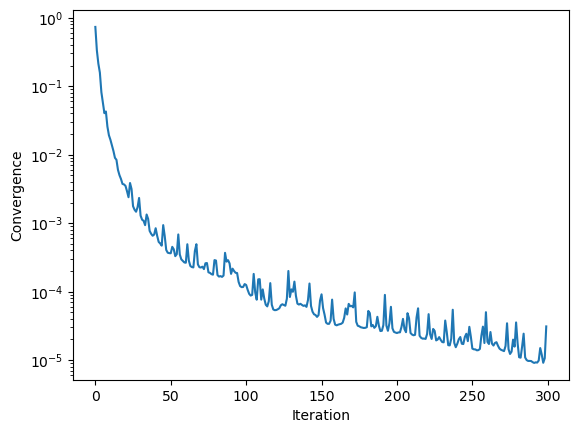

In [30]:
plt.plot(result["convergence"])
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Convergence")

In [ ]:
input = true_maps
output = result["x"]
residual = output - input

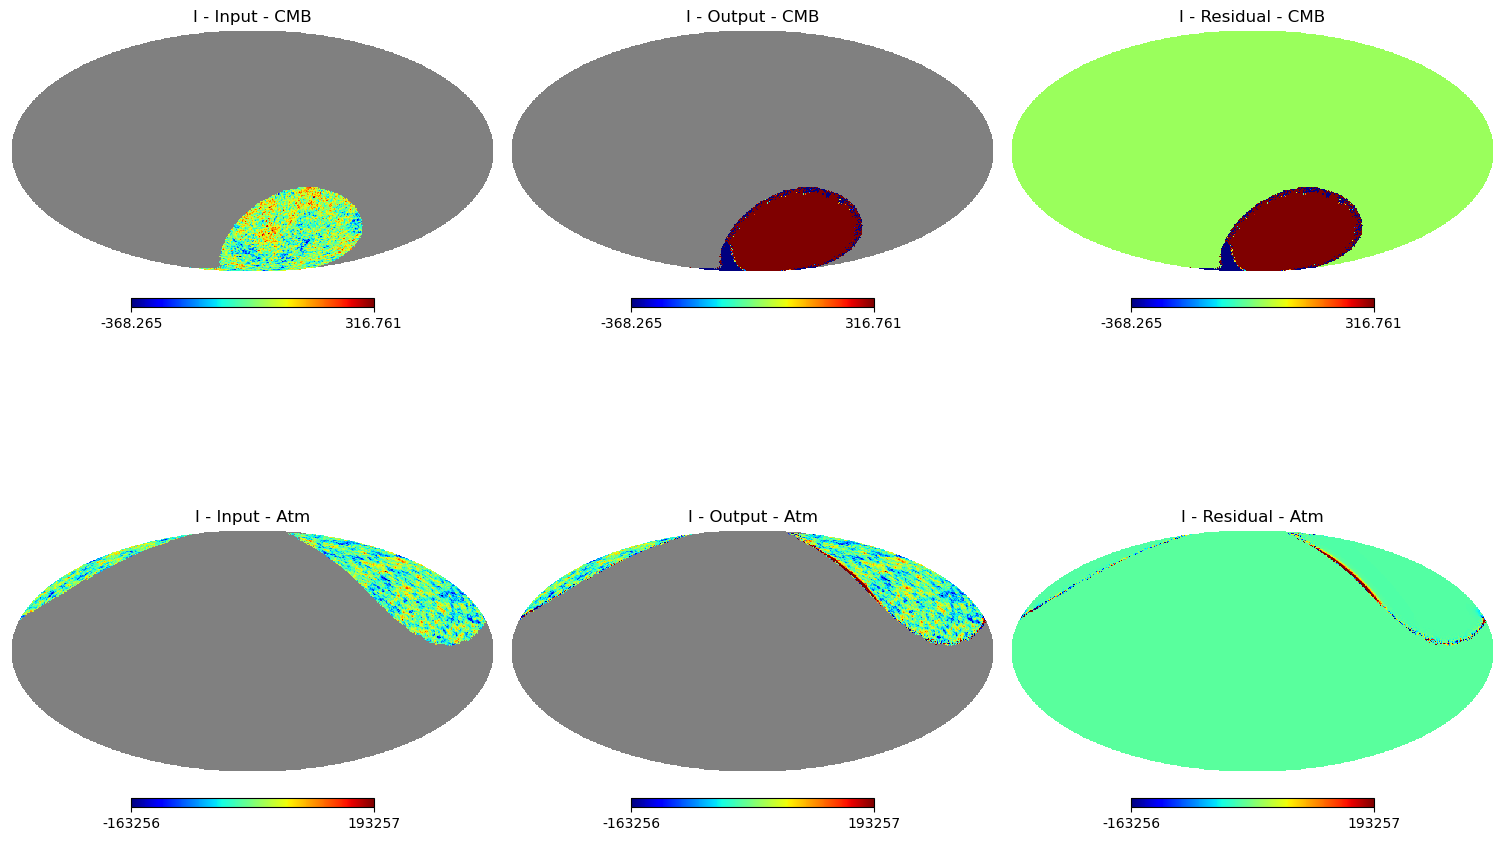

In [ ]:
plt.figure(figsize=(15, 10))
k = 1

input[0, ~seenpix_gal_wo_cut, :] = hp.UNSEEN
output[0, ~seenpix_gal_wo_cut, :] = hp.UNSEEN
input[1, ~seenpix_local_wo_cut, :] = hp.UNSEEN
output[1, ~seenpix_local_wo_cut, :] = hp.UNSEEN

istk = 0
stk = ["I", "Q", "U"]
map = ["CMB", "Atm"]

for imap in range(input.shape[0]):
    hp.mollview(
        input[imap, :, istk],
        min=np.min(input[imap, seenpix[imap], istk]),
        max=np.max(input[imap, seenpix[imap], istk]),
        cmap="jet",
        sub=(input.shape[0], 3, k),
        title=f"{stk[istk]} - Input - {map[imap]}",
        notext=True,
    )
    hp.mollview(
        output[imap, :, istk],
        min=np.min(input[imap, seenpix[imap], istk]),
        max=np.max(input[imap, seenpix[imap], istk]),
        cmap="jet",
        sub=(input.shape[0], 3, k + 1),
        title=f"{stk[istk]} - Output - {map[imap]}",
        notext=True,
    )
    hp.mollview(
        output[imap, :, istk] - input[imap, :, istk],
        min=np.min(input[imap, seenpix[imap], istk]),
        max=np.max(input[imap, seenpix[imap], istk]),
        cmap="jet",
        sub=(input.shape[0], 3, k + 2),
        title=f"{stk[istk]} - Residual - {map[imap]}",
        notext=True,
    )
    k += 3

plt.tight_layout()

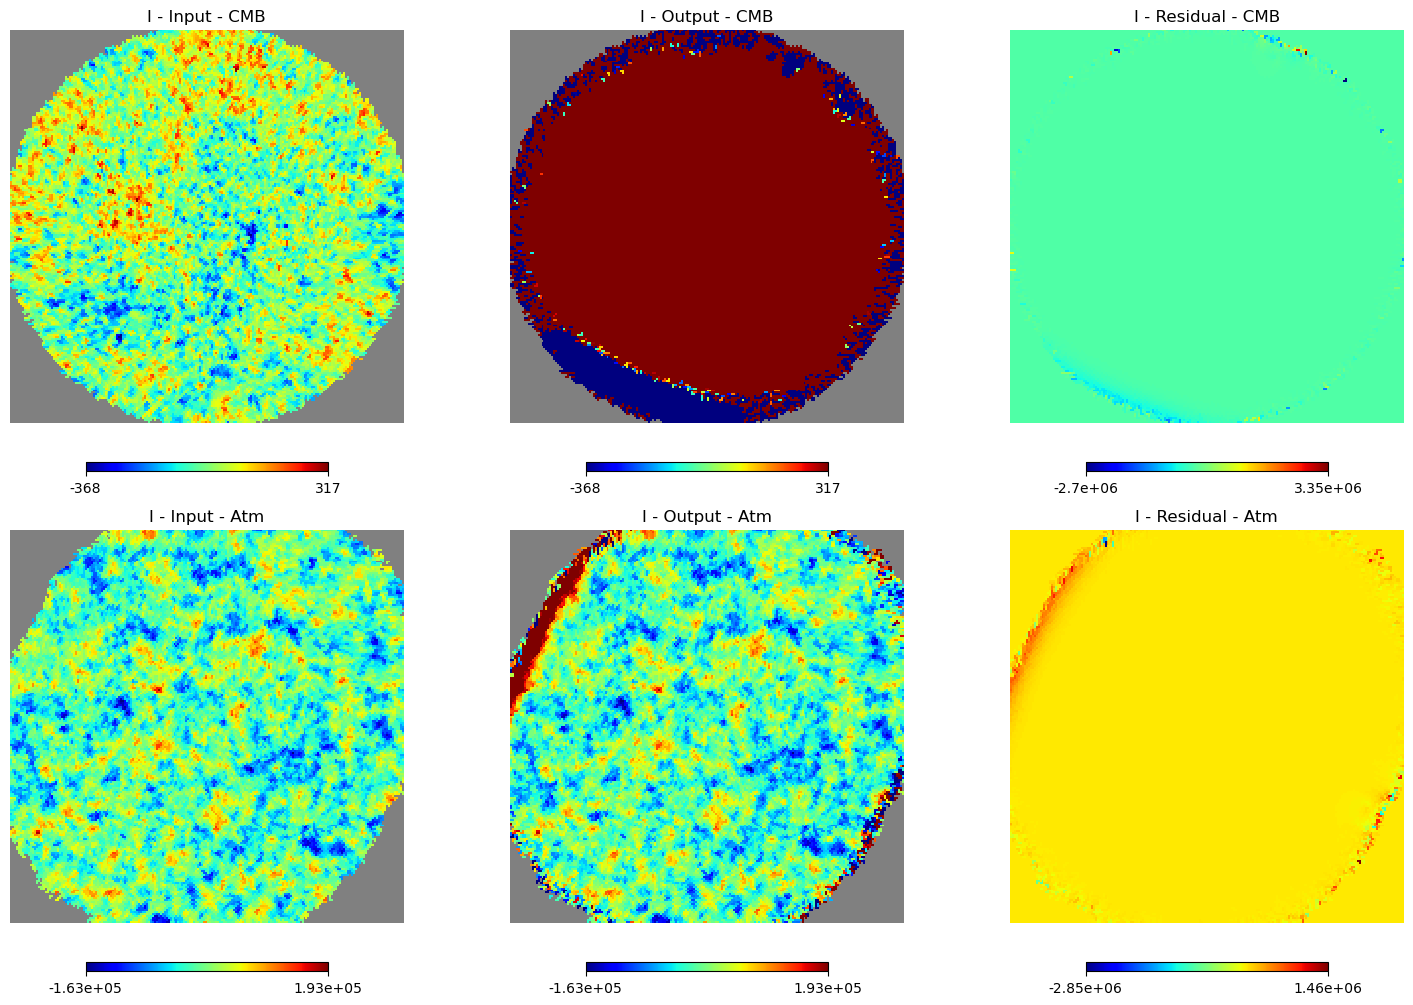

In [ ]:
plt.figure(figsize=(15, 10))
k = 1

istk = 0

reso = 25
center = [center_gal, center_local]

for imap in range(input.shape[0]):
    hp.gnomview(
        input[imap, :, istk],
        min=np.min(input[imap, seenpix[imap], istk]),
        max=np.max(input[imap, seenpix[imap], istk]),
        rot=center[imap],
        reso=reso,
        cmap="jet",
        sub=(input.shape[0], 3, k),
        title=f"{stk[istk]} - Input - {map[imap]}",
        notext=True,
    )
    hp.gnomview(
        output[imap, :, istk],
        min=np.min(input[imap, seenpix[imap], istk]),
        max=np.max(input[imap, seenpix[imap], istk]),
        rot=center[imap],
        reso=reso,
        cmap="jet",
        sub=(input.shape[0], 3, k + 1),
        title=f"{stk[istk]} - Output - {map[imap]}",
        notext=True,
    )
    hp.gnomview(
        output[imap, :, istk] - input[imap, :, istk],
        rot=center[imap],
        reso=reso,
        cmap="jet",
        sub=(input.shape[0], 3, k + 2),
        title=f"{stk[istk]} - Residual - {map[imap]}",
        notext=True,
    )
    k += 3

plt.tight_layout()

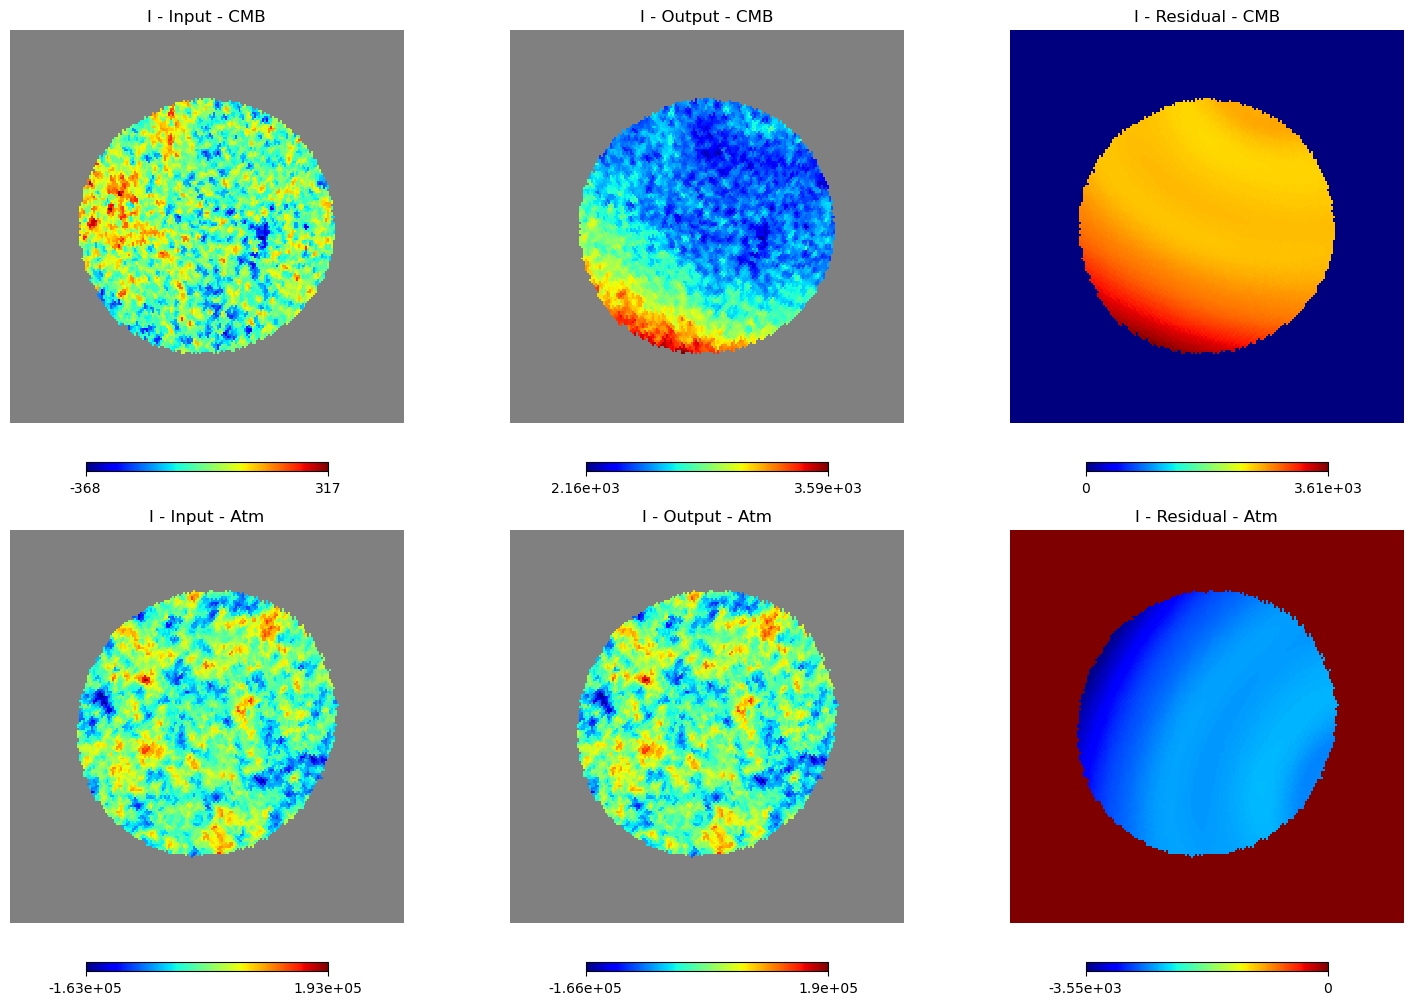

In [ ]:
plt.figure(figsize=(15, 10))
k = 1

istk = 0

input[0, ~seenpix_gal, :] = hp.UNSEEN
output[0, ~seenpix_gal, :] = hp.UNSEEN
input[1, ~seenpix_local, :] = hp.UNSEEN
output[1, ~seenpix_local, :] = hp.UNSEEN

reso = 20
center = [center_gal, center_local]

for imap in range(input.shape[0]):
    hp.gnomview(
        input[imap, :, istk],
        rot=center[imap],
        reso=reso,
        cmap="jet",
        sub=(input.shape[0], 3, k),
        title=f"{stk[istk]} - Input - {map[imap]}",
        notext=True,
    )
    hp.gnomview(
        output[imap, :, istk],
        rot=center[imap],
        reso=reso,
        cmap="jet",
        sub=(input.shape[0], 3, k + 1),
        title=f"{stk[istk]} - Output - {map[imap]}",
        notext=True,
    )
    hp.gnomview(
        output[imap, :, istk] - input[imap, :, istk],
        rot=center[imap],
        reso=reso,
        cmap="jet",
        sub=(input.shape[0], 3, k + 2),
        title=f"{stk[istk]} - Residual - {map[imap]}",
        notext=True,
    )
    k += 3

plt.tight_layout()

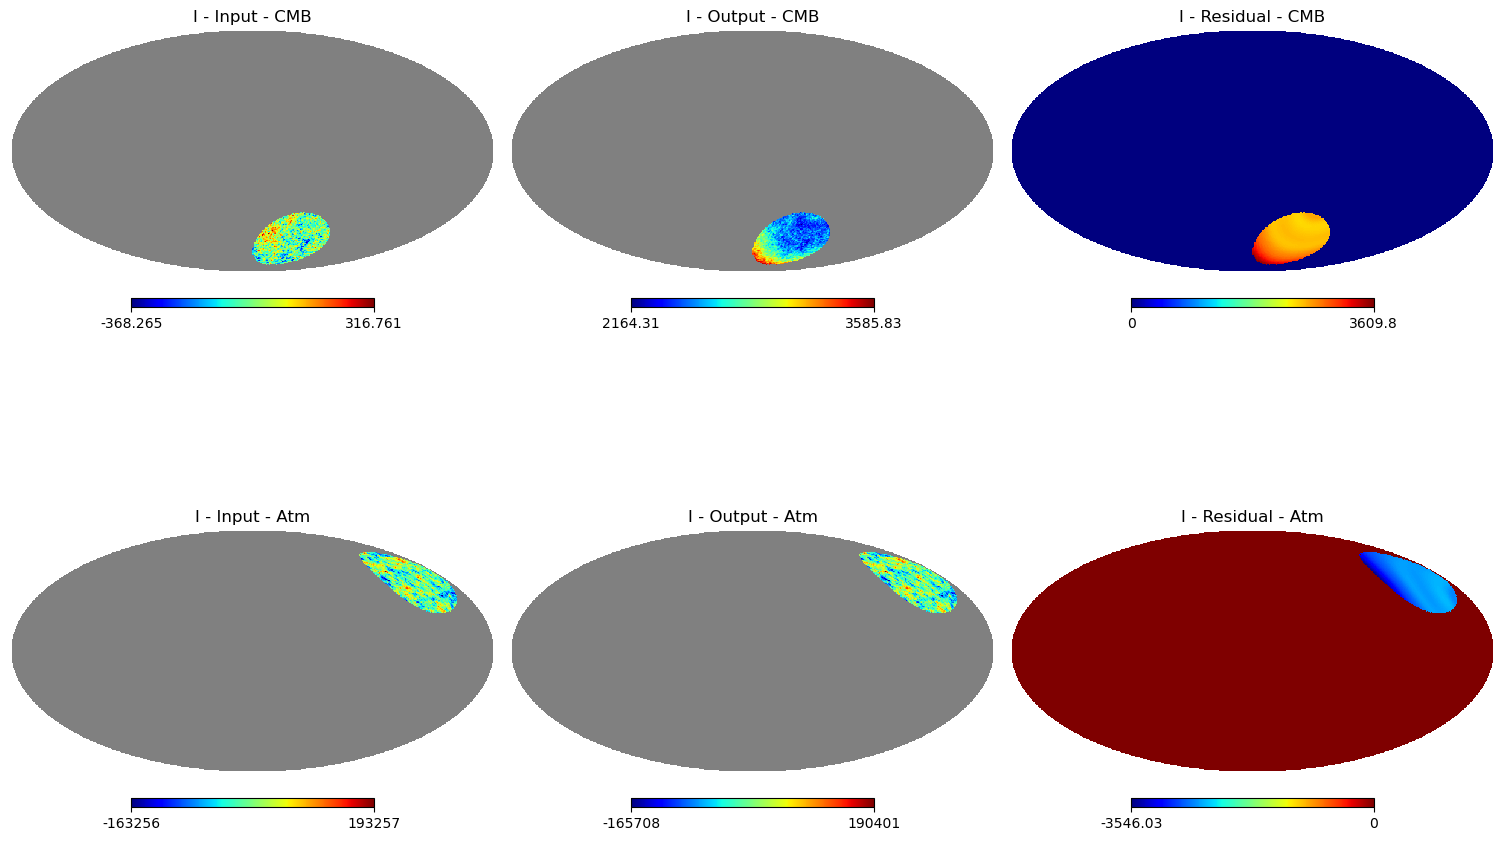

In [35]:
plt.figure(figsize=(15, 10))
k = 1

istk = 0

for imap in range(input.shape[0]):
    hp.mollview(
        input[imap, :, istk],
        cmap="jet",
        sub=(input.shape[0], 3, k),
        title=f"{stk[istk]} - Input - {map[imap]}",
        notext=True,
    )
    hp.mollview(
        output[imap, :, istk],
        cmap="jet",
        sub=(input.shape[0], 3, k + 1),
        title=f"{stk[istk]} - Output - {map[imap]}",
        notext=True,
    )
    hp.mollview(
        output[imap, :, istk] - input[imap, :, istk],
        cmap="jet",
        sub=(input.shape[0], 3, k + 2),
        title=f"{stk[istk]} - Residual - {map[imap]}",
        notext=True,
    )
    k += 3

plt.tight_layout()

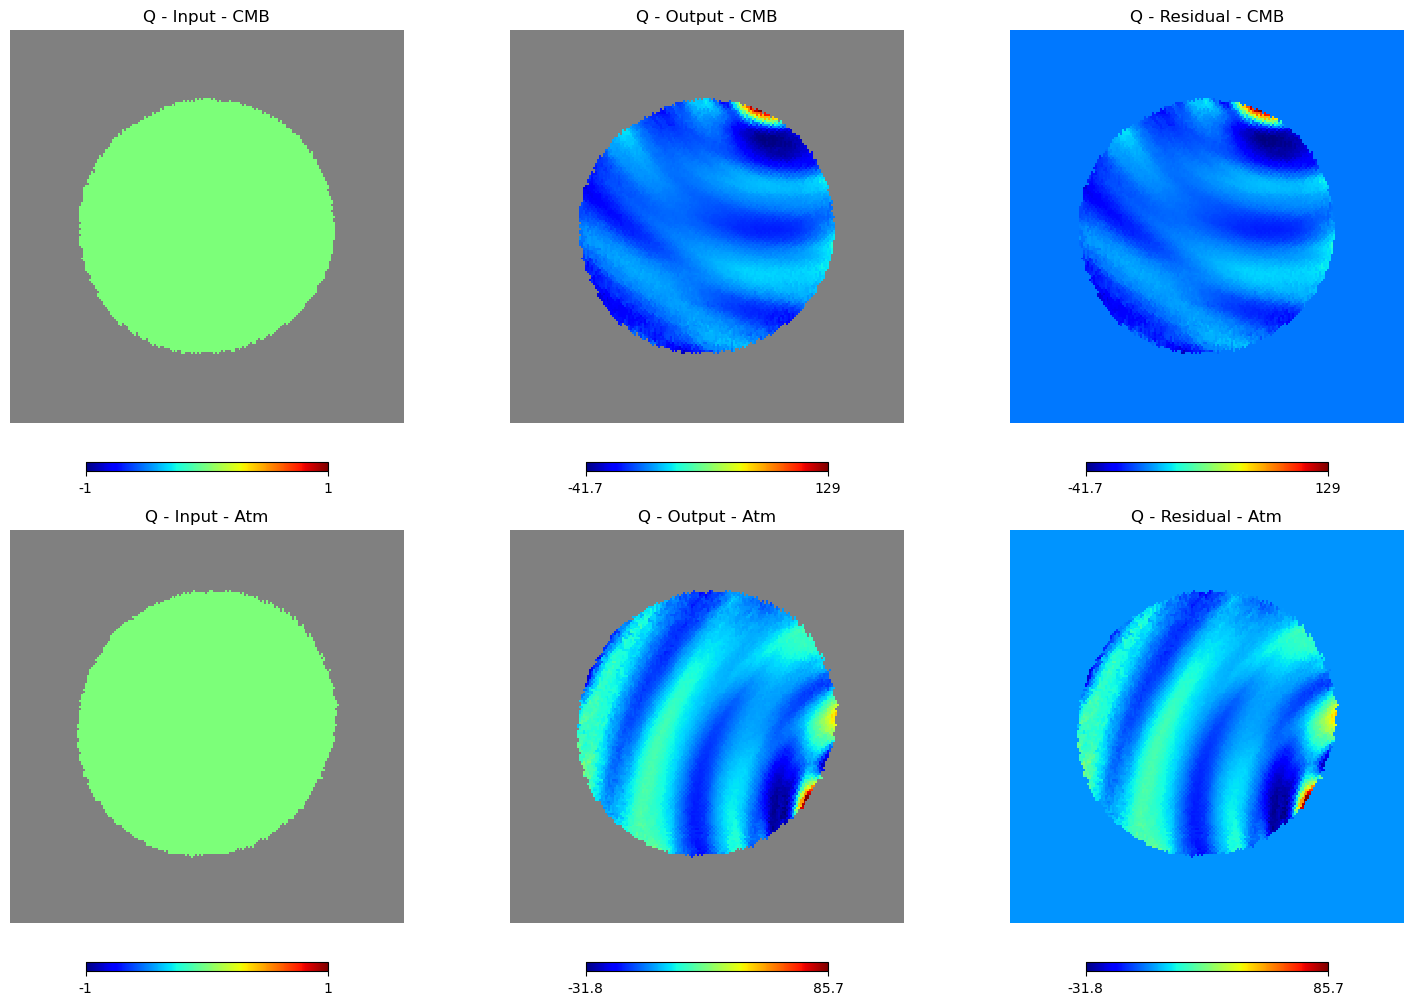

In [36]:
plt.figure(figsize=(15, 10))
k = 1

istk = 1

reso = 20
center = [center_gal, center_local]

for imap in range(input.shape[0]):
    hp.gnomview(
        input[imap, :, istk],
        rot=center[imap],
        reso=reso,
        cmap="jet",
        sub=(input.shape[0], 3, k),
        title=f"{stk[istk]} - Input - {map[imap]}",
        notext=True,
    )
    hp.gnomview(
        output[imap, :, istk],
        rot=center[imap],
        reso=reso,
        cmap="jet",
        sub=(input.shape[0], 3, k + 1),
        title=f"{stk[istk]} - Output - {map[imap]}",
        notext=True,
    )
    hp.gnomview(
        output[imap, :, istk] - input[imap, :, istk],
        rot=center[imap],
        reso=reso,
        cmap="jet",
        sub=(input.shape[0], 3, k + 2),
        title=f"{stk[istk]} - Residual - {map[imap]}",
        notext=True,
    )
    k += 3

plt.tight_layout()